# 02 · What are wind and solar power really worth?

**Research question 2:** How much is Lithuanian wind and solar electricity really worth on the day-ahead
market, and how much wind output is lost when prices turn negative?

Hourly data for January 2023 – August 2026 (the `lt_hourly` view and the `capture_rates_monthly` SQL view,
built by `src/build_db.py`). 2026 covers January–August only, so year-on-year comparisons also use
January–August of every year.

| Hypothesis | Statement |
|---|---|
| H6 | In hours when the Lithuanian price is negative, wind farms produce less electricity than the wind would allow, because some farms are deliberately stopped to avoid losses (economic curtailment). |
| H7 | The capture rate of wind and solar (their output-weighted average price divided by the plain average market price) is below 1 and fell over 2023–2026. Solar's is lower and falls faster than wind's, because all solar parks produce in the same hours and lower the price exactly when they produce. |

**Method in brief.** H6 compares actual Lithuanian wind output with the output the ERA5 wind index predicts,
using a relationship estimated month by month on hours with non-negative prices. H7 is descriptive: capture
rates by year and month, a trend test on monthly capture rates, and the hourly price profile in summer.

In [98]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

con = duckdb.connect(str(ROOT / "data" / "lt_power.duckdb"), read_only=True)
df = con.sql("SELECT * FROM lt_hourly ORDER BY ts_utc").df()
monthly_sql = con.sql("SELECT * FROM capture_rates_monthly ORDER BY month").df()
con.close()

df["year"] = df["ts_local"].dt.year
df["month"] = df["ts_local"].dt.month
df["negative"] = df["price"] < 0
JAN_AUG = df["month"] <= 8
print(f"{len(df):,} hours from {df['ts_local'].min()} to {df['ts_local'].max()}")

32,135 hours from 2023-01-01 00:00:00 to 2026-08-31 23:00:00


In [99]:
def effect(model, name, scale=1.0):
    # Coefficient of one variable with its 95% confidence interval and p-value, times `scale`.
    ci = model.conf_int().loc[name] * scale
    return pd.Series({
        "effect": model.params[name] * scale,
        "ci_low": ci.min(),
        "ci_high": ci.max(),
        "p_value": model.pvalues[name],
    })


def fmt_p(p):
    # p-value as text: a p-value is never exactly 0, so very small values are shown as an upper bound
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def show(table, decimals=3):
    # Round a results table for display; p-values below 0.001 are written as <0.001, since they are never exactly 0
    out = table.round(decimals)
    if "p_value" in out.columns:
        out["p_value"] = table["p_value"].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
    return out

## 1. Negative prices: how often, and when?

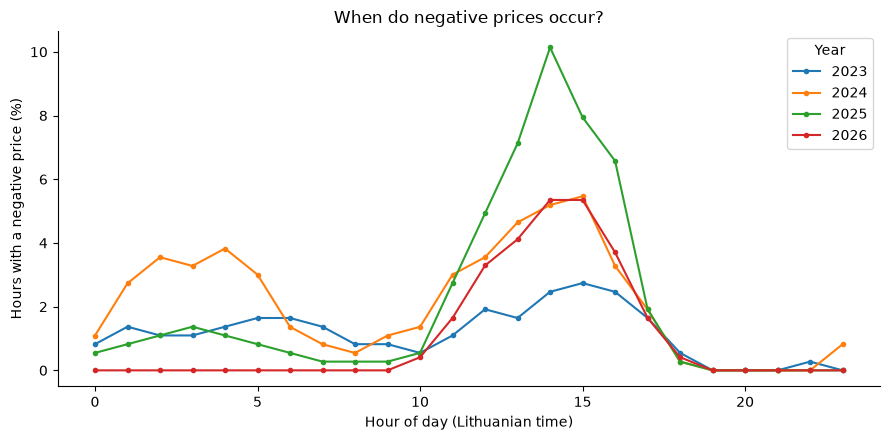

,negative hours,"share of hours, %","negative hours, Jan–Aug"
year,,,
2023,100,1.1,53
2024,186,2.1,125
2025,180,2.1,165
2026,63,1.1,63


In [100]:
negative = pd.DataFrame({
    "negative hours": df.groupby("year")["negative"].sum(),
    "share of hours, %": df.groupby("year")["negative"].mean() * 100,
    "negative hours, Jan–Aug": df[JAN_AUG].groupby("year")["negative"].sum(),
})

share_by_hour = df.groupby(["hour_local", "year"])["negative"].mean().unstack() * 100
fig, ax = plt.subplots()
for year in share_by_hour.columns:
    ax.plot(share_by_hour.index, share_by_hour[year], marker="o", ms=3, label=str(year))
ax.set_xlabel("Hour of day (Lithuanian time)")
ax.set_ylabel("Hours with a negative price (%)")
ax.set_title("When do negative prices occur?")
ax.legend(title="Year")
fig.tight_layout()
fig.savefig(FIG / "q2_negative_hours.png", dpi=150)
plt.show()
negative.round(1)

## 2. H6 — Is wind output curtailed when prices are negative?

**Idea.** The ERA5 wind index says how much the wind *could* produce; ENTSO-E says how much was produced.
For every month, a straight line from the index to actual output is fitted on hours with a non-negative price.
Estimating it month by month absorbs the growth of the fleet. The line then gives the *expected* output in every
hour. If farms are stopped when prices are negative, actual output falls below the expected output in exactly
those hours.

The slope plus intercept of each monthly line is the output at an index of 1 — a rough, data-driven measure of the
fleet's size ("implied capacity"). It is noisy from month to month, because the line is extrapolated to an index
the wind rarely reaches, but its trend can be compared with the known growth of the fleet.

Monthly fits on non-negative hours: median R² = 0.75, lowest 0.59


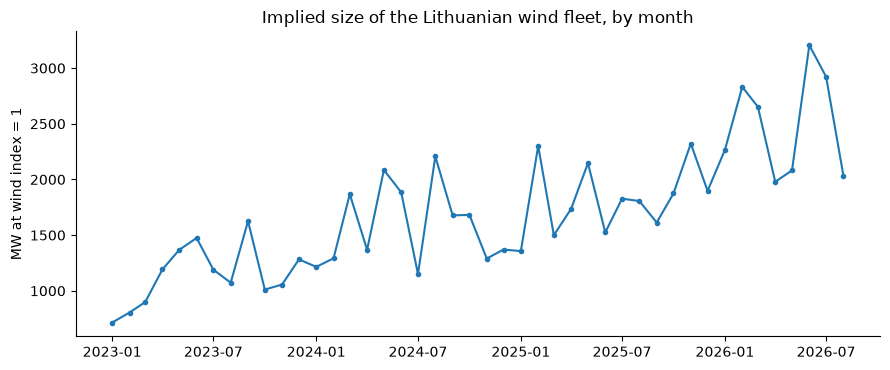

In [101]:
w = df.dropna(subset=["wind_mw", "wind_cf_lt", "price"]).copy()
w["month_id"] = w["ts_local"].dt.to_period("M").astype(str)

parts, fits = [], []
for month_id, g in w.groupby("month_id"):
    base = g[~g["negative"]]
    slope, intercept = np.polyfit(base["wind_cf_lt"], base["wind_mw"], 1)
    parts.append(g.assign(expected_mw=np.clip(intercept + slope * g["wind_cf_lt"], 0, None)))
    fits.append({"month": pd.Period(month_id), "implied capacity, MW": intercept + slope,
                 "R²": base["wind_cf_lt"].corr(base["wind_mw"]) ** 2,
                 "negative hours": int(g["negative"].sum())})
w = pd.concat(parts).sort_values("ts_utc")
fits = pd.DataFrame(fits).set_index("month")
print(f"Monthly fits on non-negative hours: median R² = {fits['R²'].median():.2f}, lowest {fits['R²'].min():.2f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(fits.index.to_timestamp(), fits["implied capacity, MW"], marker="o", ms=3)
ax.set_ylabel("MW at wind index = 1")
ax.set_title("Implied size of the Lithuanian wind fleet, by month")
fig.tight_layout()
fig.savefig(FIG / "q2_implied_capacity.png", dpi=150)
plt.show()

### 2.1 Actual against expected output
Hours are grouped by expected output. If the monthly lines fitted perfectly, the line for non-negative prices
would lie on the diagonal. Where it bends away from it, the link between the ERA5 index and output is not quite
linear. That is why the test below compares hours **with the same expected output** rather than relying on the
diagonal.

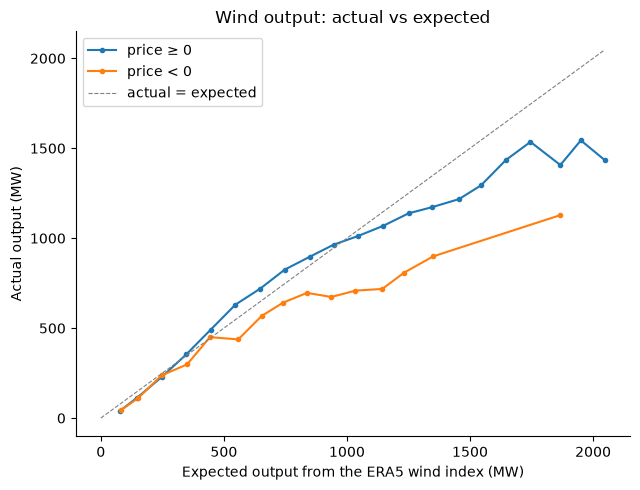

In [102]:
w["shortfall_mw"] = w["expected_mw"] - w["wind_mw"]
w["expected_bin"] = pd.cut(w["expected_mw"], np.arange(0, w["expected_mw"].max() + 100, 100))
binned = (w.groupby(["negative", "expected_bin"], observed=True)
            .agg(expected=("expected_mw", "mean"), actual=("wind_mw", "mean"), hours=("wind_mw", "size"))
            .reset_index())
binned = binned[binned["hours"] >= 10]

fig, ax = plt.subplots(figsize=(6.5, 5))
for is_negative, label in [(False, "price ≥ 0"), (True, "price < 0")]:
    g = binned[binned["negative"] == is_negative]
    ax.plot(g["expected"], g["actual"], marker="o", ms=3, label=label)
top = binned["expected"].max()
ax.plot([0, top], [0, top], color="grey", lw=0.8, ls="--", label="actual = expected")
ax.set_xlabel("Expected output from the ERA5 wind index (MW)")
ax.set_ylabel("Actual output (MW)")
ax.set_title("Wind output: actual vs expected")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q2_curtailment.png", dpi=150)
plt.show()

### 2.2 Test and a placebo by price band
For each band of expected output, the reference is the average actual output in hours with a clearly profitable
price (≥ 10 €/MWh). Every hour's gap is its output below that reference, in % — so hours are only compared with
hours of the same expected output, which removes the curvature seen above. The gap is then compared between
price bands, with standard errors clustered by month (negative-price hours come in episodes). Hours with less than
100 MW of expected output are left out, because a percentage is meaningless in calm hours.

The **0–10 €/MWh band is the placebo**: those hours have similar weather and time of day (windy, often midday),
but producing is still profitable, so no gap should appear there. The simple comparison against all non-negative
hours, without matching, is shown for reference.

In [103]:
reference = w[w["price"] >= 10].groupby("expected_bin", observed=True)["wind_mw"].mean()
w["reference_mw"] = w["expected_bin"].map(reference).astype(float)

valid = w[(w["expected_mw"] >= 100) & w["reference_mw"].notna()].copy()
valid["gap_pct"] = 100 * (1 - valid["wind_mw"] / valid["reference_mw"])
valid["band"] = pd.cut(valid["price"], [-np.inf, 0, 10, np.inf], right=False, labels=["negative", "0-10", "10+"])
valid["month_code"] = pd.factorize(valid["month_id"])[0]
cluster = {"cov_type": "cluster", "cov_kwds": {"groups": valid["month_code"].to_numpy()}}

m_h6 = smf.ols("gap_pct ~ C(band, Treatment('10+'))", data=valid).fit(**cluster)
h6 = effect(m_h6, "C(band, Treatment('10+'))[T.negative]")
h6_placebo = effect(m_h6, "C(band, Treatment('10+'))[T.0-10]")

valid["shortfall_pct"] = 100 * (valid["expected_mw"] - valid["wind_mw"]) / valid["expected_mw"]
valid["negative_int"] = valid["negative"].astype(int)
h6_simple = effect(smf.ols("shortfall_pct ~ negative_int", data=valid).fit(**cluster), "negative_int")

print(f"Hours compared: {int((valid['band'] == 'negative').sum())} negative, "
      f"{int((valid['band'] == '0-10').sum())} at 0–10 €/MWh, {int((valid['band'] == '10+').sum()):,} at ≥ 10 €/MWh")
pd.DataFrame({
    "negative price vs ≥ 10 €/MWh, same expected output": h6,
    "placebo: 0–10 €/MWh vs ≥ 10 €/MWh, same expected output": h6_placebo,
    "simple comparison, not matched (for reference)": h6_simple,
}).T.pipe(show, 2)

Hours compared: 504 negative, 2758 at 0–10 €/MWh, 26,289 at ≥ 10 €/MWh


,effect,ci_low,ci_high,p_value
"negative price vs ≥ 10 €/MWh, same expected output",18.07,9.92,26.23,<0.001
"placebo: 0–10 €/MWh vs ≥ 10 €/MWh, same expected output",0.93,-3.87,5.74,0.703
"simple comparison, not matched (for reference)",14.07,6.18,21.96,<0.001


### 2.3 How much wind energy is lost?
Lost energy is the matched reference output (section 2.2) minus actual output, summed over negative-price hours.
It is an estimate: individual hours can land above or below the reference, and only the sum is meaningful.
2026 covers January–August only.

In [104]:
w["potential_mw"] = np.where(w["negative"], w["reference_mw"].fillna(w["expected_mw"]), w["wind_mw"])
neg_w = w[w["negative"]]
lost = neg_w.groupby("year").agg(negative_hours=("wind_mw", "size"),
                                 potential_mwh=("potential_mw", "sum"),
                                 actual_mwh=("wind_mw", "sum"))
lost["curtailed_mwh"] = lost["potential_mwh"] - lost["actual_mwh"]
lost["curtailed, % of potential in these hours"] = 100 * lost["curtailed_mwh"] / lost["potential_mwh"]
lost["curtailed, % of the year's wind output"] = 100 * lost["curtailed_mwh"] / w.groupby("year")["wind_mw"].sum()
lost.round(1)

,negative_hours,potential_mwh,actual_mwh,curtailed_mwh,"curtailed, % of potential in these hours","curtailed, % of the year's wind output"
year,,,,,,
2023,100,54734.6,49515.5,5219.1,9.5,0.2
2024,186,114500.5,84071.9,30428.5,26.6,0.9
2025,180,109644.6,77838.1,31806.5,29.0,0.8
2026,63,57244.5,43642.2,13602.3,23.8,0.4


## 3. H7 — Capture rates

**Capture price** = output-weighted average price: what a technology actually earns per MWh.
**Capture rate** = capture price ÷ plain (baseload) average price. A rate below 1 means the technology produces
mostly when prices are low. The **discount** is baseload minus capture price in €/MWh.

### 3.1 By year

In [105]:
rows = []
for period, data in [("full year", df), ("January–August", df[JAN_AUG])]:
    for year, g in data.groupby("year"):
        if period == "full year" and year == df["year"].max():
            continue                                     # the last year is incomplete
        base = g["price"].mean()
        row = {"period": period, "year": year, "baseload €/MWh": base}
        for tech, col in [("wind", "wind_mw"), ("solar", "solar_mw")]:
            ok = g.dropna(subset=[col])
            captured = (ok[col] * ok["price"]).sum() / ok[col].sum()
            row[f"{tech} capture €/MWh"] = captured
            row[f"{tech} capture rate"] = captured / base
            row[f"{tech} discount €/MWh"] = base - captured
        rows.append(row)
yearly = pd.DataFrame(rows).set_index(["period", "year"])
yearly.round(3)

baseload €/MWh  wind capture €/MWh  wind capture rate  \
period         year                                                          
full year      2023          94.438              78.494              0.831   
               2024          87.341              70.837              0.811   
               2025          85.301              69.070              0.810   
January–August 2023          91.876              81.295              0.885   
               2024          86.815              73.792              0.850   
               2025          79.951              65.117              0.814   
               2026          96.958              87.391              0.901   

                     wind discount €/MWh  solar capture €/MWh  \
period         year                                             
full year      2023               15.943               85.282   
               2024               16.504               66.979   
               2025               16.232               50.085   
January–August 2023               10.581               79.696   
               2024               13.023               65.092   
               2025               14.834               44.485   
               2026                9.568               52.497   

                     solar capture rate  solar discount €/MWh  
period         year                                            
full year      2023               0.903                 9.155  
               2024               0.767                20.362  
               2025               0.587                35.216  
January–August 2023               0.867                12.181  
               2024               0.750                21.723  
               2025               0.556                35.466  
               2026               0.541                44.462

### 3.2 By month
The monthly capture rates come straight from the SQL view `capture_rates_monthly`; a quick check confirms
that pandas gives the same numbers.

SQL view vs pandas, largest difference in the monthly wind capture rate: 3.0e-15


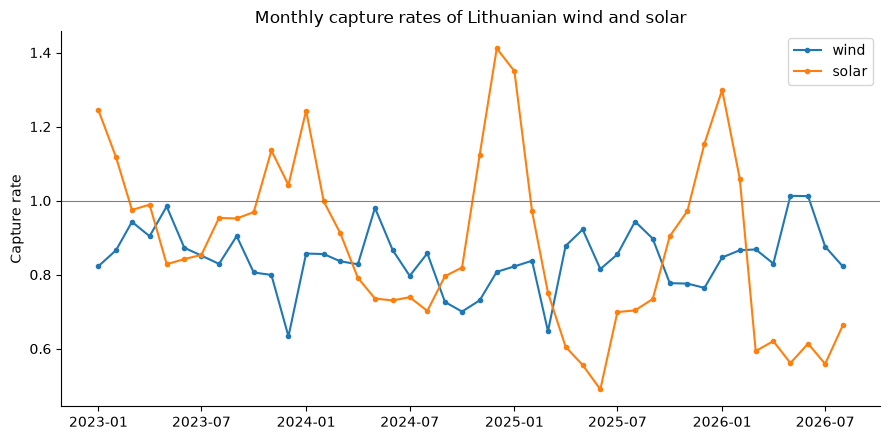

In [106]:
monthly = monthly_sql.assign(month=pd.to_datetime(monthly_sql["month"])).set_index("month")

tmp = df.assign(month_start=df["ts_local"].dt.to_period("M").dt.to_timestamp(),
                wind_value=df["wind_mw"] * df["price"])
agg = tmp.groupby("month_start").agg(wind_value=("wind_value", "sum"), wind_mwh=("wind_mw", "sum"),
                                     solar_mwh=("solar_mw", "sum"), baseload=("price", "mean"))
pandas_rate = agg["wind_value"] / agg["wind_mwh"] / agg["baseload"]
gap = (pandas_rate - monthly["wind_capture_rate"].reindex(agg.index)).abs().max()
print(f"SQL view vs pandas, largest difference in the monthly wind capture rate: {gap:.1e}")

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["wind_capture_rate"], marker="o", ms=3, label="wind")
ax.plot(monthly.index, monthly["solar_capture_rate"], marker="o", ms=3, label="solar")
ax.axhline(1, color="grey", lw=0.8)
ax.set_ylabel("Capture rate")
ax.set_title("Monthly capture rates of Lithuanian wind and solar")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q2_capture_rates_monthly.png", dpi=150)
plt.show()

### 3.3 Are capture rates falling?
Monthly capture rates are regressed on a time trend with month-of-year effects, so the seasonal cycle does not
count as a trend. Each month is weighted by the technology's output, so months with little output (solar in
winter) count less. The trend is in percentage points of capture rate per year.

In [107]:
trend_rows = {}
for tech in ["wind", "solar"]:
    t = pd.DataFrame({"rate": monthly[f"{tech}_capture_rate"], "mwh": agg[f"{tech}_mwh"]}).dropna()
    t = t[t["mwh"] > 0]
    t["trend"] = (t.index - pd.Timestamp("2023-01-01")).days / 365.25
    t["moy"] = t.index.month
    m_trend = smf.wls("rate ~ trend + C(moy)", data=t, weights=t["mwh"]).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3})
    trend_rows[tech] = effect(m_trend, "trend", 100)
trends = pd.DataFrame(trend_rows).T
show(trends, 2)

,effect,ci_low,ci_high,p_value
wind,0.25,-1.27,1.77,0.744
solar,-8.41,-10.53,-6.28,<0.001


### 3.4 The midday dip
Average price by hour of day in April–August, with the average solar output profile in the background.
If solar cannibalises its own value, the midday dip should deepen as solar capacity grows.

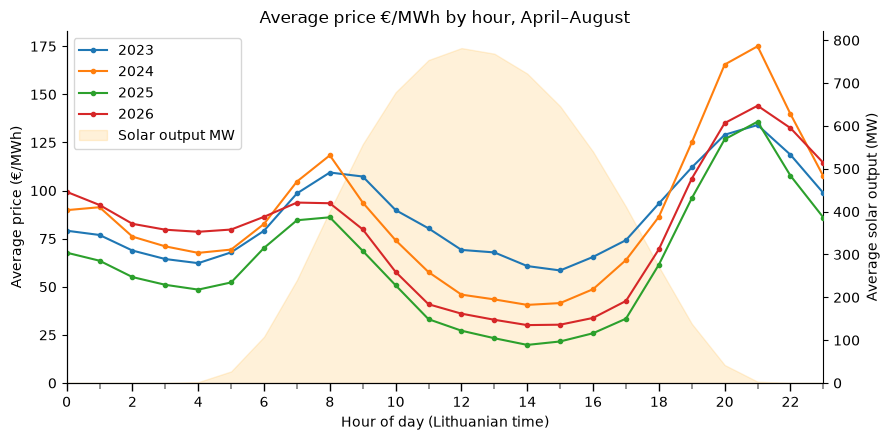

In [108]:
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

summer = df[df["month"].between(4, 8)]
profile = summer.groupby(["hour_local", "year"])["price"].mean().unstack()
solar_shape = summer.groupby("hour_local")["solar_mw"].mean()

solar_patch = mpatches.Patch(color="orange", alpha=0.15, label="Solar output MW")

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax2.fill_between(solar_shape.index, solar_shape.values, color="orange", alpha=0.15)
ax2.set_ylabel("Average solar output (MW)")
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)
for year in profile.columns:
    ax.plot(profile.index, profile[year], marker="o", ms=3, label=str(year))
    
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax.tick_params(
    axis="x",
    which="minor",
    length=4,
    width=1.2,
    color="grey",
    direction="out",  # Tick direction: 'in', 'out', or 'inout'
)
ax.tick_params(
    axis="x",
    which="major",
    length=6,
    width=1
    )

ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.set_xmargin(0)
ax.set_xlabel("Hour of day (Lithuanian time)")
ax.set_ylabel("Average price (€/MWh)")
ax.set_title("Average price €/MWh by hour, April–August")

handles, labels = ax.get_legend_handles_labels()
handles.append(solar_patch)
ax.legend(handles=handles)

fig.tight_layout()
fig.savefig(FIG / "q2_midday_dip.png", dpi=150)
plt.show()

### 3.5 Curtailment and the wind capture rate
Stopping at negative prices avoids selling at a loss, so it should raise the capture rate. Here the capture rate
of actual output is compared with that of the output the wind would have allowed (expected output in
negative-price hours, from the matched reference in section 2.2).

In [109]:
pot = w.copy()
pot["value_actual"] = pot["wind_mw"] * pot["price"]
pot["value_potential"] = pot["potential_mw"] * pot["price"]
a = pot.groupby("year").agg(value_actual=("value_actual", "sum"), mwh_actual=("wind_mw", "sum"),
                            value_potential=("value_potential", "sum"), mwh_potential=("potential_mw", "sum"),
                            baseload=("price", "mean"))
curtail_value = pd.DataFrame({
    "capture rate, actual output": a["value_actual"] / a["mwh_actual"] / a["baseload"],
    "capture rate without curtailment": a["value_potential"] / a["mwh_potential"] / a["baseload"],
})
curtail_value["gain from curtailment, pp"] = 100 * (curtail_value.iloc[:, 0] - curtail_value.iloc[:, 1])
curtail_value.round(3)

,"capture rate, actual output",capture rate without curtailment,"gain from curtailment, pp"
year,,,
2023,0.831,0.830,0.178
2024,0.811,0.803,0.772
2025,0.810,0.803,0.698
2026,0.901,0.898,0.376


### 3.6 How much money does curtailment save?
Not producing at a negative price avoids paying that price. The saving is the curtailed volume times the
(negative) price, summed per year; dividing it by the curtailed volume gives the average price in those hours.
Only annual sums are meaningful: in single hours the estimated curtailment can be negative, which is why the
tiny 2023 value comes out slightly below zero.

In [110]:
saved = ((neg_w["potential_mw"] - neg_w["wind_mw"]) * -neg_w["price"]).groupby(neg_w["year"]).sum()
pd.DataFrame({
    "curtailed MWh": lost["curtailed_mwh"],
    "cash saved, €": saved,
    "average price in these hours, €/MWh": -saved / lost["curtailed_mwh"],
}).round(1)

,curtailed MWh,"cash saved, €","average price in these hours, €/MWh"
year,,,
2023,5219.1,-3713.2,0.7
2024,30428.5,81689.4,-2.7
2025,31806.5,109413.0,-3.4
2026,13602.3,31127.3,-2.3


## 4. Summary of H6–H7

H6 is supported when, compared with profitable hours of the same expected output, output in negative-price hours is
significantly lower (p < 0.05) and the 0–10 €/MWh placebo band shows no comparable gap.

H7 has several parts: both capture rates below 1 in every year; each capture rate falling (negative, significant
trend); solar below wind now; solar falling faster. It is supported when all parts hold and partly supported when
the rates are below 1 and at least one technology's rate is falling.

In [111]:
def verdict(ok):
    return "supported" if ok else "not supported"

placebo_small = h6_placebo["p_value"] >= 0.05 or abs(h6_placebo["effect"]) < h6["effect"] / 2
h6_ok = h6["effect"] > 0 and h6["p_value"] < 0.05 and placebo_small

last_full = yearly.loc["full year"].index.max()
last_ja = yearly.loc["January–August"].index.max()
parts = {
    "both rates below 1 every year": bool((yearly[["wind capture rate", "solar capture rate"]] < 1).all().all()),
    "wind rate falling": bool(trends.loc["wind", "effect"] < 0 and trends.loc["wind", "p_value"] < 0.05),
    "solar rate falling": bool(trends.loc["solar", "effect"] < 0 and trends.loc["solar", "p_value"] < 0.05),
    "solar below wind now": bool(
        yearly.loc[("full year", last_full), "solar capture rate"] < yearly.loc[("full year", last_full), "wind capture rate"]
        and yearly.loc[("January–August", last_ja), "solar capture rate"] < yearly.loc[("January–August", last_ja), "wind capture rate"]),
    "solar falling faster": bool(trends.loc["solar", "effect"] < trends.loc["wind", "effect"]),
}
h7_verdict = ("supported" if all(parts.values())
              else "partly supported" if parts["both rates below 1 every year"]
              and (parts["wind rate falling"] or parts["solar rate falling"])
              else "not supported")
print("H7 parts:", parts)

summary = pd.DataFrame([
    ["H6", "Wind output falls below what the wind allows when prices are negative",
     f"{h6['effect']:.1f}% lower output than profitable hours with the same expected output "
     f"({fmt_p(h6['p_value'])}); placebo 0–10 €/MWh: {h6_placebo['effect']:.1f}% ({fmt_p(h6_placebo['p_value'])})",
     verdict(h6_ok)],
    ["H7", "Capture rates below 1 and falling; solar lower and falling faster",
     f"{last_full}: wind {yearly.loc[('full year', last_full), 'wind capture rate']:.2f}, "
     f"solar {yearly.loc[('full year', last_full), 'solar capture rate']:.2f}; trend per year: "
     f"wind {trends.loc['wind', 'effect']:+.1f} pp ({fmt_p(trends.loc['wind', 'p_value'])}), "
     f"solar {trends.loc['solar', 'effect']:+.1f} pp ({fmt_p(trends.loc['solar', 'p_value'])})",
     h7_verdict],
], columns=["hypothesis", "statement", "estimate", "verdict"])
summary.to_csv(FIG / "q2_summary.csv", index=False)
summary

H7 parts: {'both rates below 1 every year': True, 'wind rate falling': False, 'solar rate falling': True, 'solar below wind now': True, 'solar falling faster': True}


,hypothesis,statement,estimate,verdict
0,H6,Wind output falls below what the wind allows w...,18.1% lower output than profitable hours with ...,supported
1,H7,Capture rates below 1 and falling; solar lower...,"2025: wind 0.81, solar 0.59; trend per year: w...",partly supported


## 5. Interpretation

**1. Wind output lost at negative prices.** When the price is negative, wind output is 18% lower than in clearly
profitable hours (≥ 10 €/MWh) with the same expected output (95% CI 10–26%, p < 0.001, standard errors clustered by
month; Cameron & Miller, 2015). The actual-vs-expected chart shows the pattern. There is no gap in calm hours,
where there is little to hold back, and a gap of roughly 20–30% once expected output passes about 500 MW.

The lost energy grew about sixfold after 2023: roughly 5 GWh in 2023, 30 GWh in 2024, 32 GWh in 2025 and 14 GWh in
January–August 2026. Two things drove this. Negative hours almost doubled (100 → 186 → 180). The share of available
wind held back in those hours also rose, from 9.5% to 27–29% (24% in 2026). On average the fleet now holds back
about 165–215 MW per negative hour, against about 50 MW in 2023. The pooled 18% is lower than these yearly shares
because it weights all hours equally and includes 2023. In volume terms the loss is still small: under 1% of annual
wind output in every year.

The placebo supports reading this as economic curtailment. In the 0–10 €/MWh band, weather and time of day are
similar but producing still pays, and the gap there is only 0.9% (CI −3.9 to 5.7%, p = 0.70). Its confidence
interval does not overlap the negative-price one. Output drops where the price crosses zero, not wherever prices
are low or the wind is strong, which is what price-driven stopping predicts. A flaw in the ERA5 index or a
windy-weather effect would have shown up in the placebo band too. The unmatched comparison gives a similar 14%, so
the result does not hinge on the matching. The test cannot, however, separate farms stopping on their own from
grid-operator curtailment in the same hours. H6 is supported.

**2. Capture rates and discounts.** Both technologies sell below baseload in every year: their capture rate, which
Hirth (2013) calls the value factor, is below 1.

- **Wind:** the capture rate was 0.83 in 2023 and 0.81 in 2024 and 2025. That is a steady discount of about 16
  €/MWh (capture prices of 69–78 €/MWh against a baseload of 85–94).
- **Solar:** it started ahead of wind at 0.90 in 2023 (9 €/MWh below baseload), then fell to 0.77 in 2024 (20 €/MWh
  below) and 0.59 in 2025 (35 €/MWh below).
- **January–August 2026:** solar captured 52.5 €/MWh against a baseload of 97.0 (rate 0.54, discount 44.5 €/MWh).
  Wind captured 87.4 €/MWh (rate 0.90).

Solar is now clearly the more cannibalised technology. A solar MWh was worth 98% of a wind MWh in January–August
2023, and about 60% in January–August 2026. López Prol et al. (2020) find the same ranking in California, where
cannibalisation is also stronger for solar than for wind.

The reason is timing. All solar produces in the same midday hours of the same months: every park in Lithuania and
its neighbours, plus rooftop panels. Because sunshine is correlated across borders and markets are coupled, neighbours' solar lowers prices in the
same hours too; Stiewe et al. (2025) show this cross-border cannibalisation for interconnected European markets. Each new megawatt therefore adds supply exactly when the
others are producing, and lowers the price it is paid. Solar also loses on the season, because most of its output
comes in April–August, when prices are usually below the annual average. Wind follows weather systems rather than
the clock. Its output is spread over day and night and leans towards the colder, pricier months. Its surplus hours
are scattered, so its discount has not grown with the fleet.

**3. Are capture rates falling?** Solar's is; wind's is not. After removing the seasonal cycle, the solar capture
rate falls by 8.4 percentage points (pp) a year (95% CI 6.3–10.5, p < 0.001, Newey–West standard errors; Newey &
West, 1987). Wind's trend is +0.25 pp a year and indistinguishable from zero (CI −1.3 to +1.8, p = 0.74). H7 is
therefore only partly supported: both rates are below 1 in every year, and solar is now lower (it was higher in 2023) and falling faster, but
wind is not falling.

The midday dip shows the mechanism. In April–August the average price at 14:00 fell from about 60 €/MWh in 2023 to
about 40 in 2024 and 20 in 2025 (about 30 in 2026). Meanwhile the evening peak around 21:00 stayed at 135–175
€/MWh. The trough lines up with the solar output curve, so solar's hours are exactly the ones that became cheaper.
Wind produces around the clock, so a cheaper midday lowers its capture price roughly in step with the baseload and
leaves its rate unchanged. López Prol et al. (2020) even find that more solar can raise wind's value factor, which
may help explain wind's high rate in January–August 2026 (0.90).

Negative prices tell the same story. They became more frequent: 53, 125 and 165 hours in January–August of 2023,
2024 and 2025. They also moved to midday. In 2025 about one 14:00 hour in ten was negative. The night-time negative
hours seen in 2023–2025, when there is no solar, are absent in 2026, although 2026 covers only January–August
and hourly averaging can hide negative quarter-hours (point 6). Negative prices have become a solar
problem.

2026 is a useful check. Negative hours fell to 63 in January–August, yet the solar capture rate still slipped
(0.556 → 0.541) and the discount widened. The reason is that prices rose mostly outside solar hours. In the summer
profile, night prices were up about 30 €/MWh on 2025, and midday prices only about 10. Cannibalisation is about how
cheap solar's hours are compared with the rest of the day, not just about negative prices. The fall has slowed
sharply, though: −1.5 pp, against −12 and −19 pp in the previous two January–August comparisons. The −8.4 pp trend
should not be extrapolated in a straight line.

**4. Curtailment and the wind capture rate.** Curtailment raises the wind capture rate by only 0.2 pp in 2023, 0.8
pp in 2024, 0.7 pp in 2025 and 0.4 pp in January–August 2026. In 2024–2025 that is about 0.6–0.7 €/MWh on the
capture price, under 1% of it.

Most of this gain is arithmetic rather than money. Suppose the curtailed MWh (0.8–0.9% of annual output) had been
sold at exactly zero. The capture rate would still have been about 0.6–0.7 pp lower, which is nearly the whole
measured gain. The cash actually saved is only the negative price times the curtailed volume: for the whole fleet about
€80,000 in 2024, €110,000 in 2025 and €30,000 in January–August 2026 (section 3.6). Prices in curtailed hours
were on average only about 2–3.5 €/MWh below zero.

For a wind farm owner this means three things:

- **Curtailment should be routine.** It is rational at negative prices. The owner should offer with a price floor
  near zero, and make sure control systems and contracts (PPA negative-price clauses, support-scheme rules) allow
  it.
- **It does not fix the real problem.** That problem is the ~16 €/MWh discount earned across many low-but-positive
  hours.
- **Expect about 1% of annual output to go unsold.** A fully market-exposed farm will lose more than the fleet
  average suggests (see point 6). This belongs in yield and revenue forecasts.

**5. What this means for a company like Ignitis.**

*PPA pricing.* A pay-as-produced wind PPA can be priced as the baseload forward times a stable capture rate of
about 0.81, roughly 16 €/MWh below baseload. It needs a margin for volume and shape risk, but wind's flat history
makes that risk comparatively easy to price. Solar is harder. A price based on 2023–2024 capture rates (0.77–0.90)
would overstate what solar output is worth today (0.54). The uncertainty about where the rate settles argues for a
bigger risk discount, shorter tenors, or selling solar only inside a shaped or hybrid product. Negative-price
clauses are a detail in wind PPAs but increasingly important for solar, since negative hours are now midday hours.

*Merchant exposure.* For merchant wind, the main risk is the baseload price level, not a collapsing capture rate.
That level moved between about 80 and 97 €/MWh across the January–August periods. Merchant solar carries both
risks: in January–August 2026 a solar MWh earned 52.5 €/MWh, against 87.4 €/MWh for wind. Solar is the part of a
portfolio that most needs contracting, hedging or storage.

*Storage (Kruonis, batteries).* The price profile is the business case. In April–August the average price at 21:00
exceeded that at 14:00 by about 115–135 €/MWh in 2024–2026, against about 75 €/MWh in 2023. In negative hours, now
almost all at midday, storage is paid to charge. For a company that owns both solar and storage, storage is also a
natural hedge: what solar loses to the midday dip, storage earns on the spread. The literature likewise
finds that storage and price-responsive demand substantially reduce the value drop of wind and solar (see the
review in Stiewe et al., 2025).

The same logic says spreads will narrow as more storage is built in the region. The higher midday prices and fewer negative hours in 2026 may already reflect new flexibility, though the
notebook does not test this, and relative to night and evening prices the dip did not shrink (point 3). Business cases
should not assume today's spreads will last. They should also add balancing and reserve revenues, which these
day-ahead numbers leave out.

*Hybrid wind–solar parks.* A hybrid's capture rate is just the output-weighted average of its parts. Two-thirds
wind and one-third solar would have given about 0.74 in 2025, so hybridisation does not raise the value of each
MWh. The gains lie elsewhere:

- Wind is strongest in the colder months and solar in summer, so the two rarely run at full power together.
- One grid connection can serve both and is used for more hours.
- The combined profile is smoother and easier to sell as a shaped PPA.

The strongest case is wind plus solar plus a battery on one connection, with the battery moving midday solar into
the evening peak.

**6. Limits.**

*Small solar.* If the ENTSO-E data (ENTSO-E, n.d.) miss prosumer and other small solar, solar volumes are
understated. The capture rate itself should be little affected, because it depends on the shape of output rather
than its volume, and rooftop panels follow almost the same daily curve. But unmeasured solar still lowers midday
prices, and most prosumers do not react to prices at all. The midday dip is therefore caused by more solar than the
data show.

*Feed-in tariffs.* The EU's 2014 state-aid guidelines require renewable support schemes to give no incentive to
generate at negative prices (European Commission, 2014, section 3.3.2), but older parks on fixed feed-in tariffs
have no reason to stop. The 18% (and the 24–29% of potential) is therefore an average over parks that respond and
parks that do not. A fully market-exposed farm probably curtails considerably more. Part of the rise since 2023 may
also reflect a changing fleet (new market-based parks, expiring tariffs) rather than changed behaviour.

*ERA5.* The index comes from coarse reanalysis weather data on a grid of roughly 30 km (Hersbach et al., 2020,
2023), and expected output comes from a simple monthly line. The fits explain a median 75% of hourly variation
(lowest 59%), the relationship bends at high output, and the implied fleet size is noisy. Matching on expected
output and the placebo protect against errors common to all windy hours. They do not protect against errors that
happen to coincide with negative-price hours, such as a new park connecting mid-month. Only annual sums of lost
energy should be read, not single hours.

*Hourly averaging.* The European day-ahead market has cleared in 15-minute periods since 1 October 2025 (SDAC,
2025). Averaging to hours hides negative quarter-hours inside hours with a positive average. Negative hours are
therefore undercounted from October 2025, and part of the 2026 fall may be an artefact. Some curtailment also lands
in the 0–10 and ≥ 10 €/MWh bands, which biases the H6 estimate towards zero, so the estimate is conservative.
Hourly capture prices also miss how output and price move within the hour.

*Other.* 2026 covers January–August only. With 44 months of data, the solar trend rests mostly on 2024–2025. All
capture rates are day-ahead only, leaving out intraday and balancing prices, imbalance costs, guarantees of origin
and support payments.

### References

- Cameron, A. C., & Miller, D. L. (2015). A practitioner's guide to cluster-robust inference. *Journal of Human
  Resources, 50*(2), 317–372. <https://doi.org/10.3368/jhr.50.2.317>
- ENTSO-E. (n.d.). *Transparency Platform: Actual generation per production type [16.1.B&C] and day-ahead prices
  [12.1.D], bidding zone Lithuania* [Data set; January 2023 – August 2026]. <https://transparency.entsoe.eu/>
- European Commission. (2014). Guidelines on State aid for environmental protection and energy 2014–2020 (2014/C
  200/01). *Official Journal of the European Union*, C 200, 28 June 2014, 1–55.
- Hersbach, H., Bell, B., Berrisford, P., et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the
  Royal Meteorological Society, 146*(730), 1999–2049. <https://doi.org/10.1002/qj.3803>
- Hersbach, H., Bell, B., Berrisford, P., et al. (2023). *ERA5 hourly data on single levels from 1940 to present*
  [Data set]. Copernicus Climate Change Service (C3S) Climate Data Store (CDS).
  <https://doi.org/10.24381/cds.adbb2d47>
- Hirth, L. (2013). The market value of variable renewables: The effect of solar wind power variability on their
  relative price. *Energy Economics, 38*, 218–236. <https://doi.org/10.1016/j.eneco.2013.02.004>
- López Prol, J., Steininger, K. W., & Zilberman, D. (2020). The cannibalization effect of wind and solar in the
  California wholesale electricity market. *Energy Economics, 85*, 104552.
  <https://doi.org/10.1016/j.eneco.2019.104552>
- Newey, W. K., & West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation
  consistent covariance matrix. *Econometrica, 55*(3), 703–708. <https://doi.org/10.2307/1913610>
- SDAC. (2025, October 1). *SDAC: Go-live of 15-minute Market Time Unit in Day Ahead Market Coupling successful as
  of September 30, 2025* [Press release, published by Austrian Power Grid].
  <https://markt.apg.at/en/news-press/sdac-go-live-of-15-minute-market-time-unit-in-day-ahead-market-coupling-successful-as-of-september-30-2025/>
- Stiewe, C., Xu, A. L., Eicke, A., & Hirth, L. (2025). Cross-border cannibalization: Spillover effects of wind and
  solar energy on interconnected European electricity markets. *Energy Economics, 143*, 108251.
  <https://doi.org/10.1016/j.eneco.2025.108251>